In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve().parent if Path.cwd().name == 'code' else Path.cwd().resolve()
df = pd.read_csv(root / 'artifacts' / 'results_grid.csv')

agg = (
    df.groupby(['n_params', 'train_tokens_real'], as_index=False)
      .agg(
          val_loss=('val_loss', 'mean'),
          mu=('mu_landscape', 'mean'),
          flops=('flops_estimate', 'mean'),
      )
)

agg['log_ratio'] = np.log10(agg['train_tokens_real'] / agg['n_params'])
agg['logC'] = np.log10(agg['flops'])
agg['log_mu'] = np.log10(np.clip(agg['mu'].to_numpy(), 1e-12, None))

print('rows:', len(agg))

rows: 600


In [2]:
def make_bands(data: pd.DataFrame, band_col: str, n_bands: int = 4, q_low: float = 0.2, q_high: float = 0.8, min_points: int = 16) -> pd.DataFrame:
    centers = np.quantile(data[band_col], np.linspace(q_low, q_high, n_bands))
    width = max(0.05, 0.5 * float(np.median(np.diff(np.sort(centers))))) if n_bands > 1 else 0.10
    rows = []
    for i, c in enumerate(centers, start=1):
        g = data[np.abs(data[band_col] - c) <= width].copy()
        if len(g) < min_points:
            continue
        g['band_id'] = i
        rows.append(g)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

isoFLOPs rows: 451


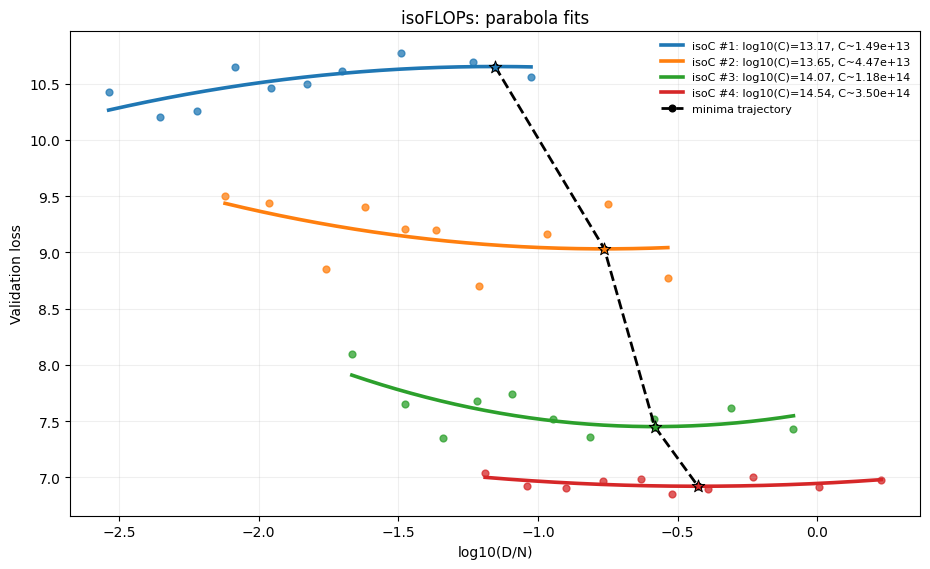

In [3]:
iso_flops = make_bands(agg, band_col='logC', n_bands=4)
print('isoFLOPs rows:', len(iso_flops))

fig, ax = plt.subplots(figsize=(9.4, 5.8))
palette = plt.get_cmap('tab10').colors
minima = []

for band_id, g in iso_flops.groupby('band_id'):
    color = palette[(int(band_id) - 1) % len(palette)]
    g = g.sort_values('log_ratio').copy()
    g['bin'] = pd.qcut(g['log_ratio'], q=min(10, max(4, len(g) // 4)), duplicates='drop')
    s = g.groupby('bin', observed=False).agg(
        x=('log_ratio', 'median'),
        y=('val_loss', 'median'),
        n=('val_loss', 'size'),
        ord=('logC', 'median'),
    ).dropna()
    s = s[s['n'] >= 3].sort_values('x')
    if len(s) < 5:
        continue

    x = s['x'].to_numpy()
    y = s['y'].to_numpy()

    c2, c1, c0 = np.polyfit(x, y, 2)
    xs = np.linspace(x.min(), x.max(), 240)
    ys = c2 * xs * xs + c1 * xs + c0

    c_level = float(s['ord'].median())
    c_value = 10.0 ** c_level
    label = f'isoC #{int(band_id)}: log10(C)={c_level:.2f}, C~{c_value:.2e}'
    ax.plot(xs, ys, lw=2.6, color=color, label=label)
    ax.scatter(x, y, s=24, color=color, alpha=0.75)

    if abs(c2) > 1e-12:
        x_min = float(np.clip(-c1 / (2.0 * c2), x.min(), x.max()))
        y_min = float(c2 * x_min * x_min + c1 * x_min + c0)
    else:
        j = int(np.argmin(y))
        x_min = float(x[j])
        y_min = float(y[j])

    minima.append((float(s['ord'].median()), x_min, y_min))
    ax.scatter([x_min], [y_min], s=90, marker='*', color=color, edgecolor='black', linewidth=0.7, zorder=6)

if len(minima) >= 2:
    m = pd.DataFrame(minima, columns=['ord', 'x', 'y']).sort_values('ord')
    ax.plot(m['x'], m['y'], color='black', lw=2.0, ls='--', marker='o', ms=4.8, label='minima trajectory')

ax.set_title('isoFLOPs: parabola fits')
ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation loss')
ax.grid(True, alpha=0.2)
ax.legend(frameon=False, fontsize=8, loc='best')
fig.tight_layout()
plt.show()

iso-mu rows: 395


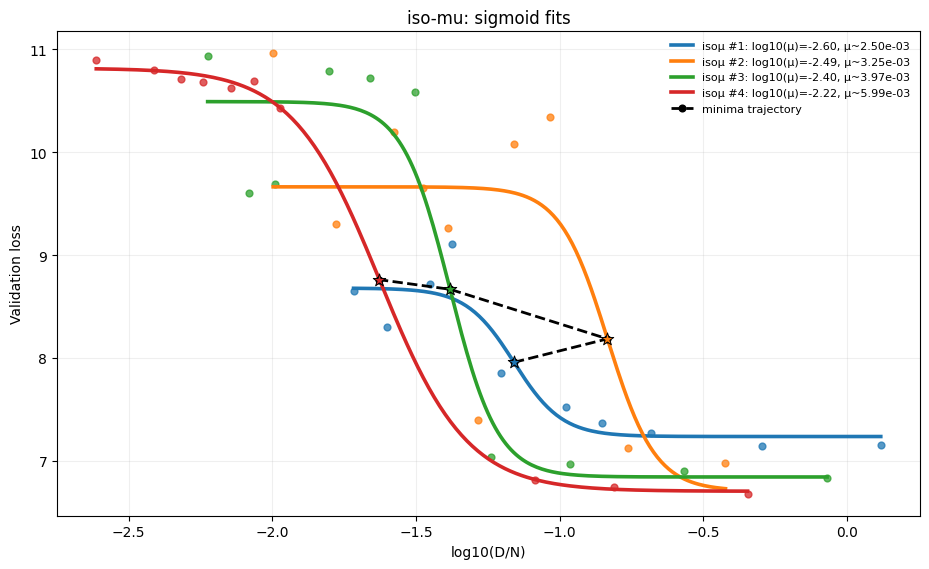

In [4]:
iso_mu = make_bands(agg, band_col='log_mu', n_bands=4)
print('iso-mu rows:', len(iso_mu))

fig, ax = plt.subplots(figsize=(9.4, 5.8))
palette = plt.get_cmap('tab10').colors
minima = []

for band_id, g in iso_mu.groupby('band_id'):
    color = palette[(int(band_id) - 1) % len(palette)]
    g = g.sort_values('log_ratio').copy()
    g['bin'] = pd.qcut(g['log_ratio'], q=min(10, max(4, len(g) // 4)), duplicates='drop')
    s = g.groupby('bin', observed=False).agg(
        x=('log_ratio', 'median'),
        y=('val_loss', 'median'),
        n=('val_loss', 'size'),
        ord=('log_mu', 'median'),
    ).dropna()
    s = s[s['n'] >= 3].sort_values('x')
    if len(s) < 5:
        continue

    x = s['x'].to_numpy()
    y = s['y'].to_numpy()

    best = None
    for c in np.linspace(0.8, 6.0, 24):
        for d in np.linspace(x.min(), x.max(), 24):
            t = np.tanh(c * (x - d))
            X = np.column_stack([np.ones_like(x), t])
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            y_hat = X @ beta
            rmse = float(np.sqrt(np.mean((y - y_hat) ** 2)))
            if best is None or rmse < best[0]:
                best = (rmse, float(beta[0]), float(beta[1]), float(c), float(d))

    _, a0, a1, c_best, d_best = best
    xs = np.linspace(x.min(), x.max(), 240)
    ys = a0 + a1 * np.tanh(c_best * (xs - d_best))

    mu_level = float(s['ord'].median())
    mu_value = 10.0 ** mu_level
    label = f'isoμ #{int(band_id)}: log10(μ)={mu_level:.2f}, μ~{mu_value:.2e}'
    ax.plot(xs, ys, lw=2.6, color=color, label=label)
    ax.scatter(x, y, s=24, color=color, alpha=0.75)

    x_mid = float(np.clip(d_best, x.min(), x.max()))
    y_mid = float(a0 + a1 * np.tanh(c_best * (x_mid - d_best)))
    minima.append((float(s['ord'].median()), x_mid, y_mid))
    ax.scatter([x_mid], [y_mid], s=90, marker='*', color=color, edgecolor='black', linewidth=0.7, zorder=6)

if len(minima) >= 2:
    m = pd.DataFrame(minima, columns=['ord', 'x', 'y']).sort_values('ord')
    ax.plot(m['x'], m['y'], color='black', lw=2.0, ls='--', marker='o', ms=4.8, label='minima trajectory')

ax.set_title('iso-mu: sigmoid fits')
ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation loss')
ax.grid(True, alpha=0.2)
ax.legend(frameon=False, fontsize=8, loc='best')
fig.tight_layout()
plt.show()

In [ ]:
iso_flops = make_bands(agg, band_col='logC', n_bands=4)
iso_mu = make_bands(agg, band_col='log_mu', n_bands=4)

rows_c = []
for _, g in iso_flops.groupby('band_id'):
    g = g.sort_values('log_ratio').copy()
    g['bin'] = pd.qcut(g['log_ratio'], q=min(10, max(4, len(g) // 4)), duplicates='drop')
    s = g.groupby('bin', observed=False).agg(
        x=('log_ratio', 'median'),
        y=('val_loss', 'median'),
        n=('val_loss', 'size'),
        level=('logC', 'median'),
    ).dropna()
    s = s[s['n'] >= 3].sort_values('x')
    if len(s) < 5:
        continue
    j = int(np.argmin(s['y'].to_numpy()))
    rows_c.append({'level': float(s['level'].median()), 'x_opt': float(s.iloc[j]['x'])})
front_c = pd.DataFrame(rows_c).sort_values('level').reset_index(drop=True)

rows_m = []
for _, g in iso_mu.groupby('band_id'):
    g = g.sort_values('log_ratio').copy()
    g['bin'] = pd.qcut(g['log_ratio'], q=min(10, max(4, len(g) // 4)), duplicates='drop')
    s = g.groupby('bin', observed=False).agg(
        x=('log_ratio', 'median'),
        y=('val_loss', 'median'),
        n=('val_loss', 'size'),
        level=('log_mu', 'median'),
    ).dropna()
    s = s[s['n'] >= 3].sort_values('x')
    if len(s) < 5:
        continue
    j = int(np.argmin(s['y'].to_numpy()))
    rows_m.append({'level': float(s['level'].median()), 'x_opt': float(s.iloc[j]['x'])})
front_m = pd.DataFrame(rows_m).sort_values('level').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8))

if len(front_c) >= 2:
    x = front_c['level'].to_numpy()
    y = front_c['x_opt'].to_numpy()
    b = np.polyfit(x, y, 1)
    xf = np.linspace(x.min(), x.max(), 120)
    yf = b[0] * xf + b[1]
    axes[0].scatter(x, y, s=42, color='tab:blue')
    axes[0].plot(xf, yf, lw=2.3, color='tab:blue')
    axes[0].set_title('isoFLOPs: optimal balance vs compute')
    axes[0].set_xlabel('log10(C)')
    axes[0].set_ylabel('optimal log10(D/N)')
    axes[0].grid(True, alpha=0.22)

if len(front_m) >= 2:
    x = front_m['level'].to_numpy()
    y = front_m['x_opt'].to_numpy()
    b = np.polyfit(x, y, 1)
    xf = np.linspace(x.min(), x.max(), 120)
    yf = b[0] * xf + b[1]
    axes[1].scatter(x, y, s=42, color='tab:green')
    axes[1].plot(xf, yf, lw=2.3, color='tab:green')
    axes[1].set_title('iso-mu: optimal balance vs mu-level')
    axes[1].set_xlabel('log10(mu)')
    axes[1].set_ylabel('optimal log10(D/N)')
    axes[1].grid(True, alpha=0.22)

fig.tight_layout()
plt.show()